## Chapter 19 - Complete machine learning projects

*This notebook contains all the sample code in Chapter 19.*

## Outline

- [A reusable model-comparison workflow](#Reusable)
- [Project 1: California housing regression](#Project1)
- [Project 2: numerical and categorical features](#Project2)
- [Project 3: missing values](#Project3)
    - [Explicit missing values](#Explicit)
    - [Disguised missing values](#Disguised)
- [Project 4: handwritten-digit classification](#Project4)
- [Project 5: face recognition with SVMs](#Project5)
- [Project 6: SMS spam detection](#Project6)
    - [A bag-of-words baseline](#BoW)
    - [TF-IDF and hyperparameter selection](#TFIDF)
    - [Incremental and out-of-core learning](OOC)
- [A minimal web application](#Web)

## A reusable model-comparison workflow <a id="Reusable"></a>

When several estimators have to be compared, it is convenient to store them in a dictionary and evaluate them with the same cross-validation splits and the same metrics. The following helper function can be used for both regression and classification:

In [1]:
import pandas as pd
from sklearn.model_selection import cross_validate

def compare_models(models, X, y, cv, scoring, loss_metrics=()):
    """Evaluate multiple estimators with the same CV protocol."""
    rows = []

    for name, estimator in models.items():
        scores = cross_validate(
            estimator,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        row = {
            "model": name,
            "fit_time_mean": scores["fit_time"].mean(),
            "fit_time_std": scores["fit_time"].std()
        }

        for metric_name in scoring:
            values = scores[f"test_{metric_name}"]
            if metric_name in loss_metrics:
                values = -values

            row[f"{metric_name}_mean"] = values.mean()
            row[f"{metric_name}_std"] = values.std()

        rows.append(row)

    return pd.DataFrame(rows)

## Project 1: California housing regression <a id="Project1"></a>

The **California Housing** dataset is a regression benchmark in which the target is the median house value for a California district, expressed in hundreds of thousands of US dollars. Each district is described by eight numerical features, including median income, average occupancy, geographical position, and statistics derived from the local housing population.

The dataset can be loaded directly from Scikit-learn as a Pandas data frame:

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print(X.shape)
print(X.head())
print(y.describe())

(20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


Before fitting any model, we inspect the distributions, correlations, and possible outliers. The target is added temporarily to the data frame only for exploratory analysis:

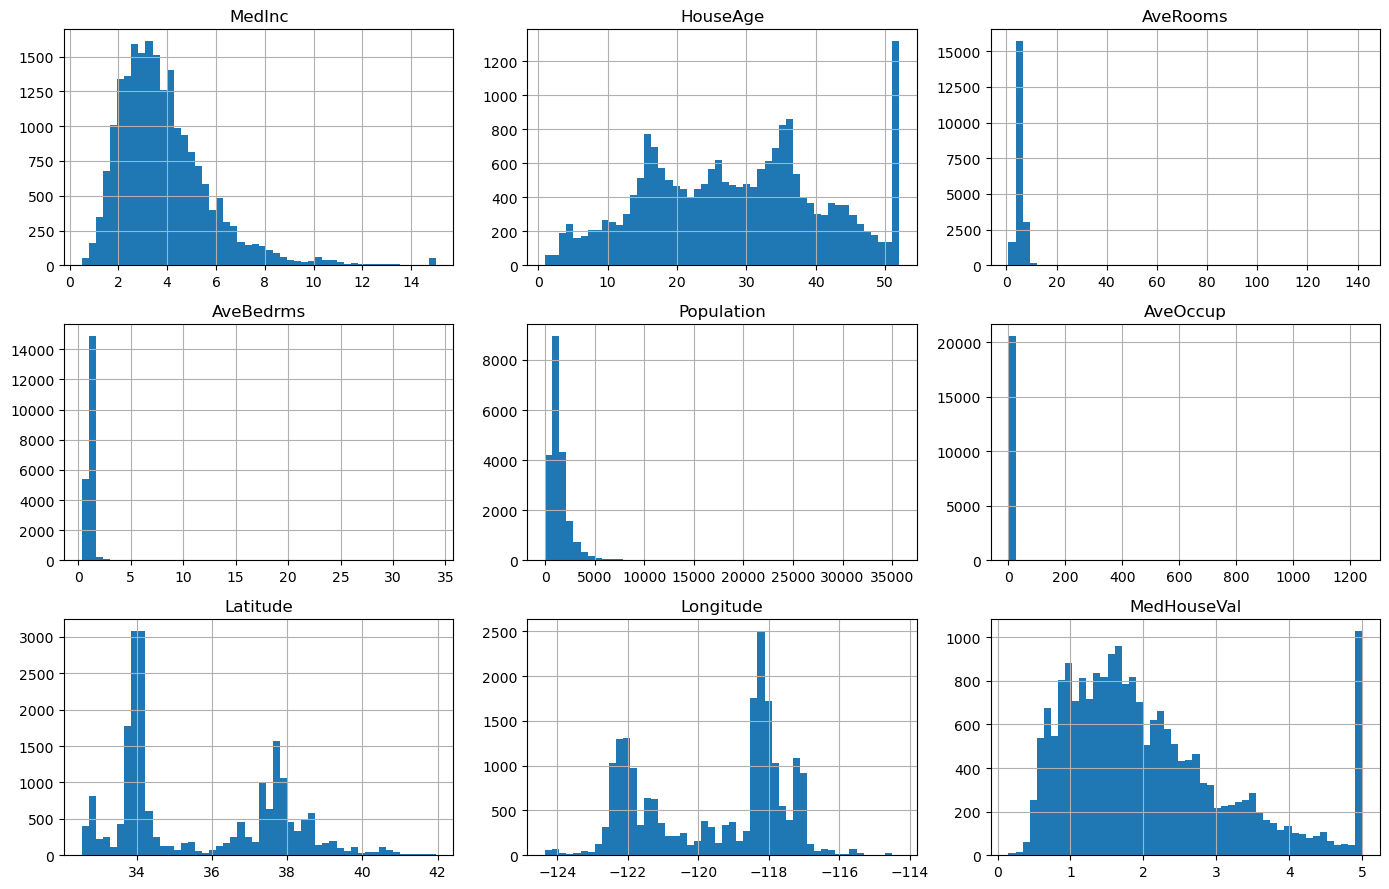

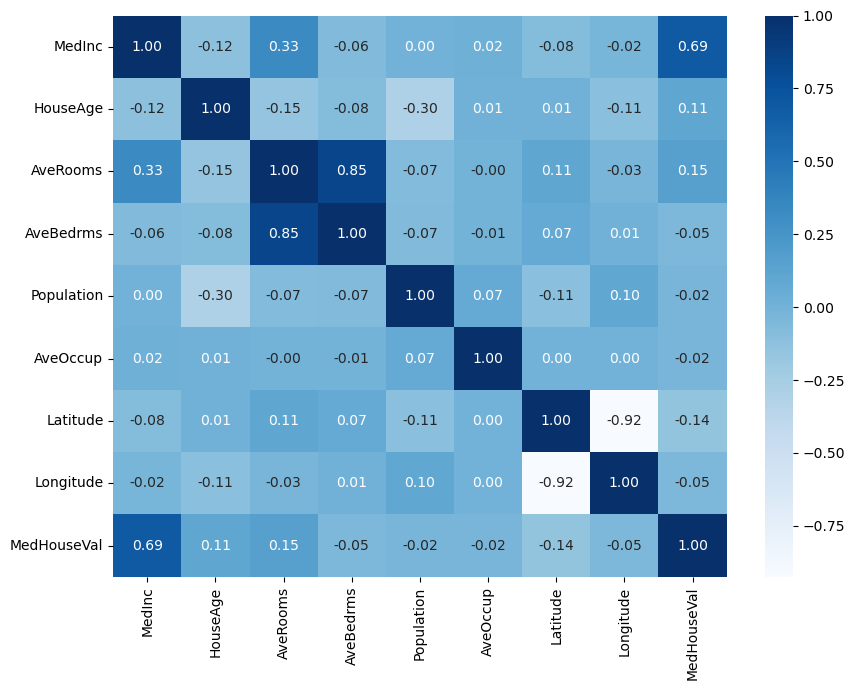

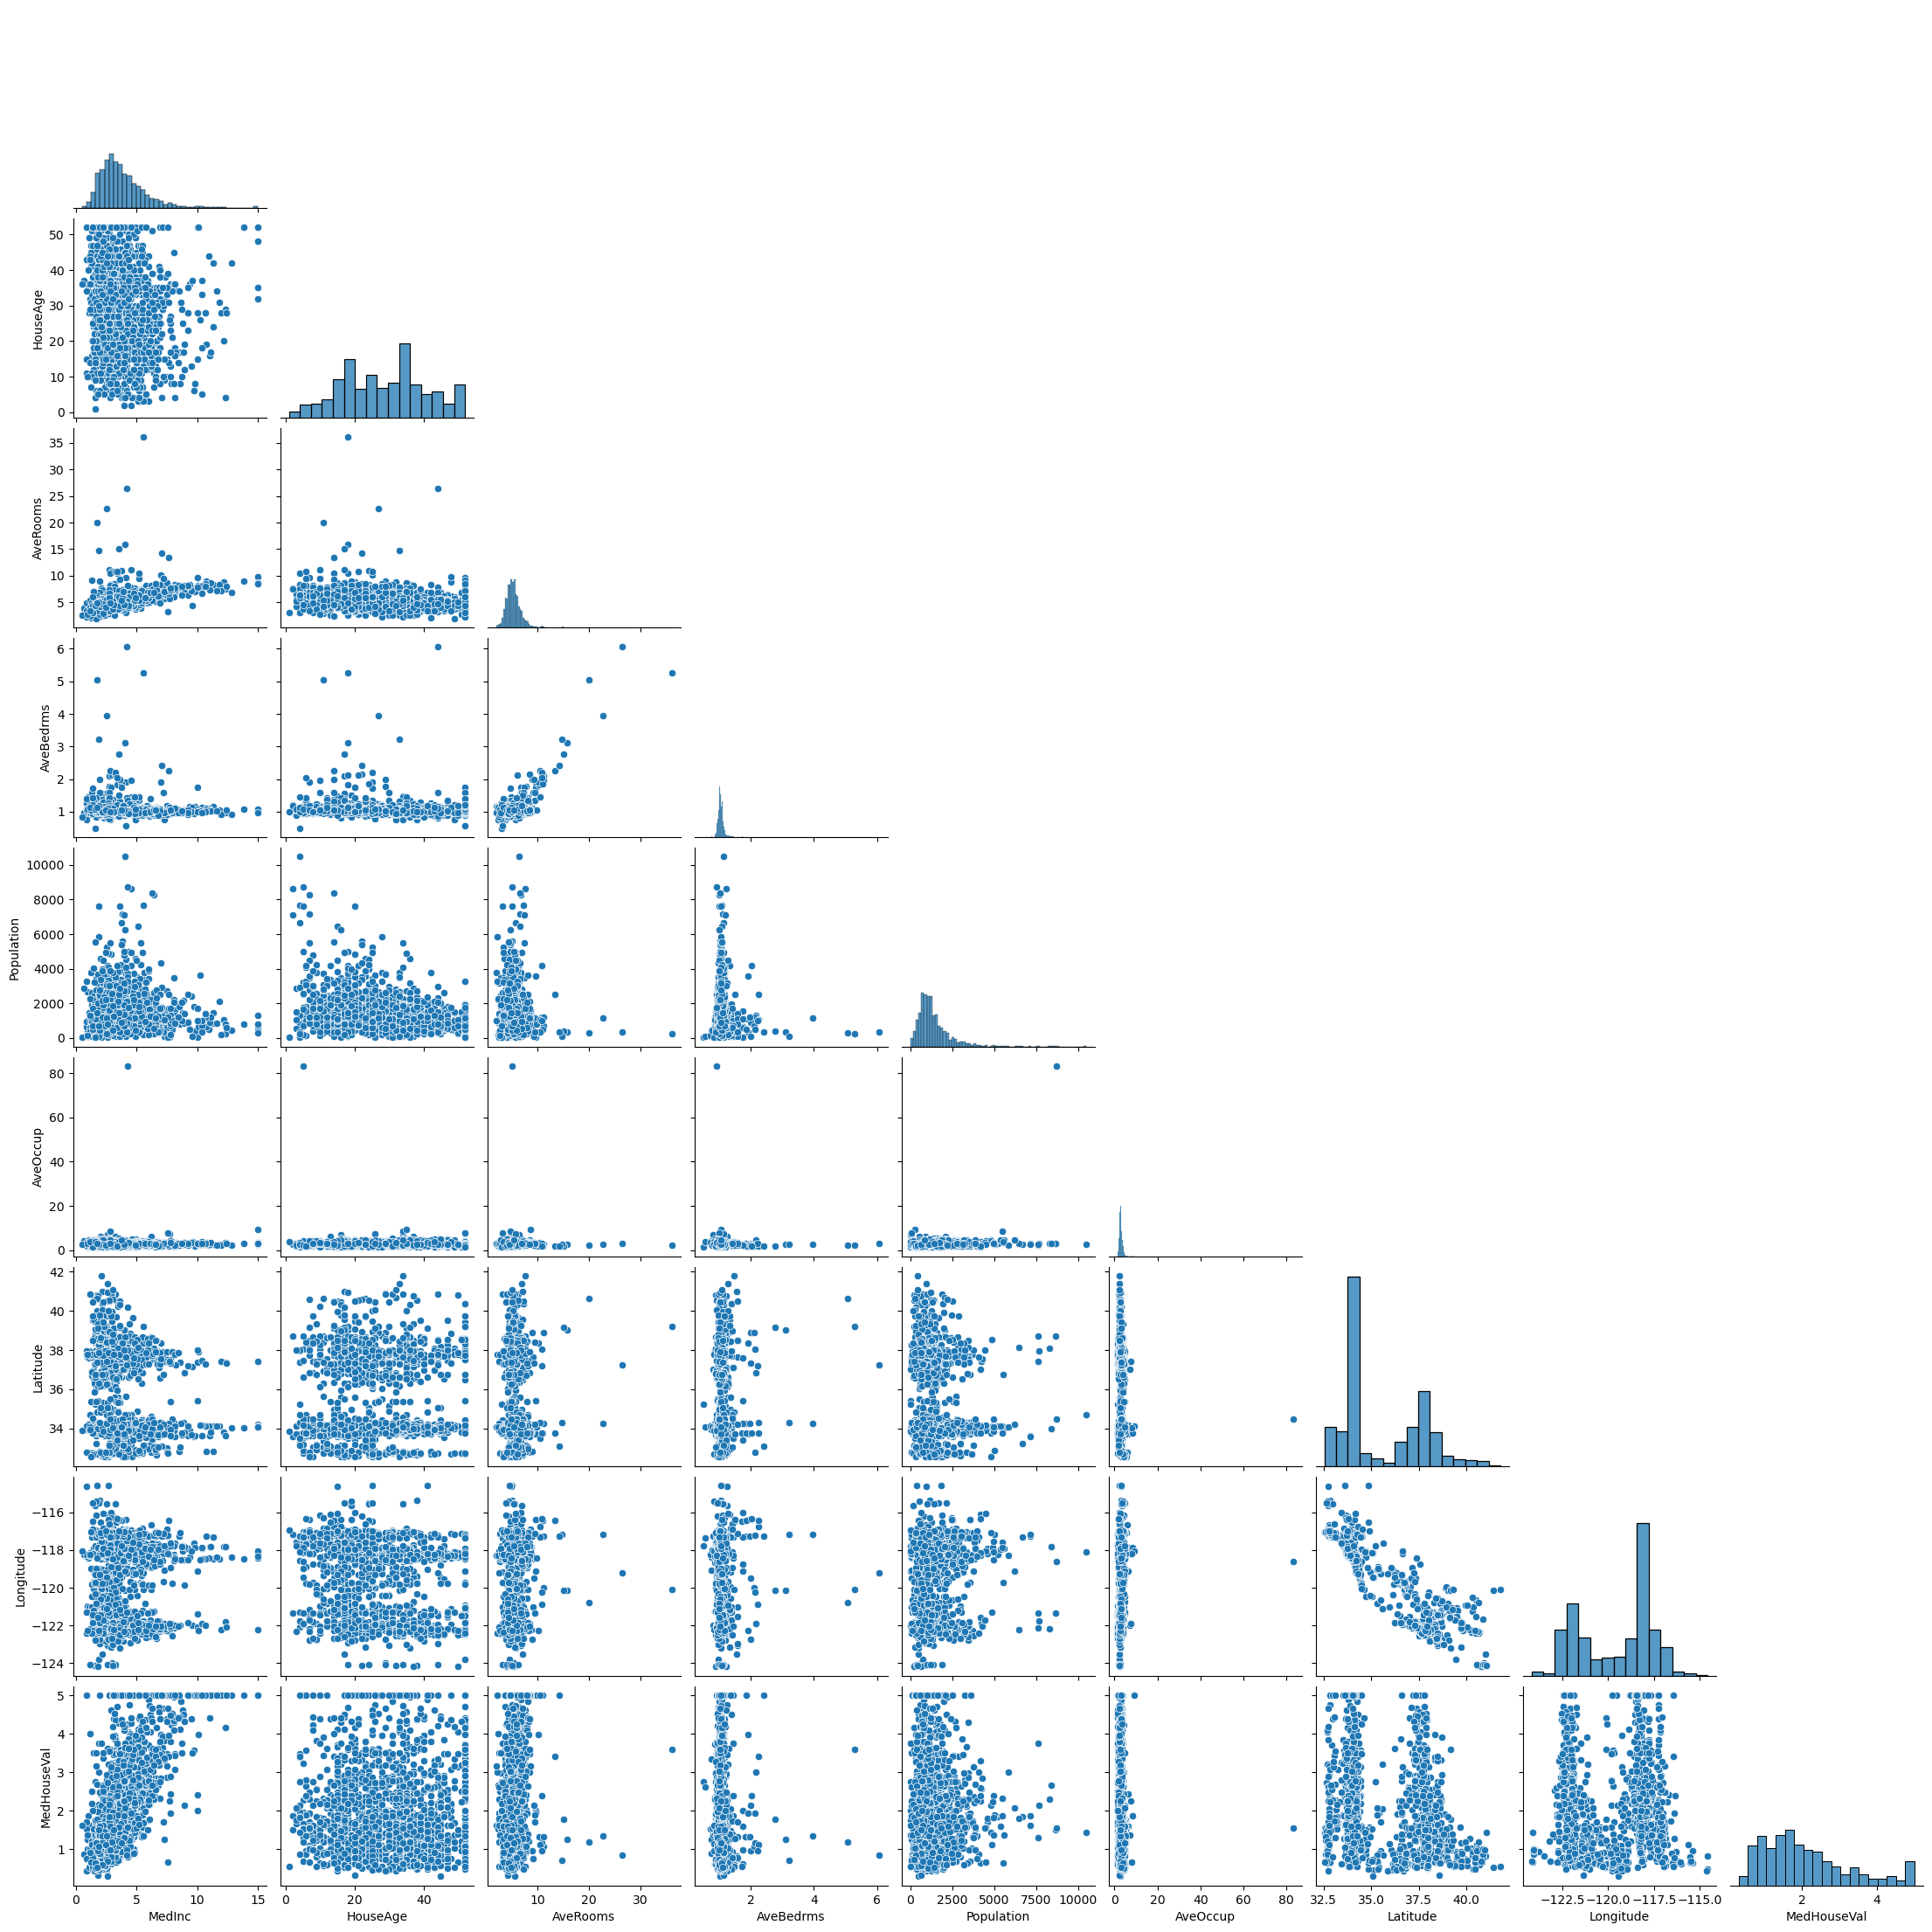

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

eda = X.copy()
eda["MedHouseVal"] = y

eda.hist(bins=50, figsize=(14, 9))
plt.tight_layout()

plt.figure(figsize=(9, 7))
sns.heatmap(eda.corr(numeric_only=True),
            cmap="Blues",
            annot=True,
            fmt=".2f")
plt.tight_layout()

# A pairplot of all 20,640 observations is unnecessarily expensive.
eda_sample = eda.sample(n=1500, random_state=42)
sns.pairplot(eda_sample, corner=True, diag_kind="hist")

We therefore reserve the test set immediately:

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

We compare a constant baseline with linear, local, kernel-based, and ensemble regressors. Models that depend on distances or coefficient regularization are combined with standardization. Feature selection and PCA are also included as pipeline steps, so they are fitted only on the training portion of each fold. 

In [5]:
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

models = {
    "Median baseline": DummyRegressor(strategy="median"),

    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),

    "kNN": make_pipeline(
        StandardScaler(),
        KNeighborsRegressor(n_neighbors=15, weights="distance")
    ),

    "RBF SVR": make_pipeline(
        StandardScaler(),
        SVR(C=10.0, epsilon=0.10, gamma="scale")
    ),

    "F-test + Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=4)),
        ("regressor", Ridge(alpha=1.0))
    ]),

    "PCA + Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("regressor", Ridge(alpha=1.0))
    ]),

    "Random forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Histogram gradient boosting": HistGradientBoostingRegressor(
        learning_rate=0.08,
        max_iter=300,
        random_state=42
    )
}

We use five-fold cross-validation on the training data and compare MAE, RMSE, and $R^2$:

In [6]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv_results = compare_models(
    models,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    loss_metrics={"mae", "rmse"}
)

cv_results = cv_results.sort_values("mae_mean")
print(cv_results[
    ["model", "mae_mean", "mae_std",
     "rmse_mean", "r2_mean", "fit_time_mean"]
])

                         model  mae_mean   mae_std  rmse_mean   r2_mean  \
7  Histogram gradient boosting  0.305452  0.007391   0.462475  0.839969   
6                Random forest  0.333151  0.005292   0.509605  0.805659   
3                      RBF SVR  0.376530  0.007013   0.568086  0.758410   
2                          kNN  0.440368  0.006658   0.637125  0.696133   
1                        Ridge  0.529056  0.009381   0.720509  0.611457   
4               F-test + Ridge  0.594952  0.009307   0.799987  0.521072   
5                  PCA + Ridge  0.609364  0.010247   0.813629  0.504624   
0              Median baseline  0.885966  0.009233   1.187806 -0.055714   

   fit_time_mean  
7       1.597265  
6      47.537658  
3      25.133412  
2       0.046836  
1       0.019598  
4       0.022593  
5       0.023437  
0       0.004250  


After selecting the workflow with the smallest cross-validated MAE, we fit a fresh clone on the complete training set and evaluate it once on the test set:

C:\Users\miche\anaconda3\envs\mtf\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\subprocess.py", line 1538, in _execute_chi

Selected workflow: Histogram gradient boosting
Test MAE:  0.295
Test RMSE: 0.446
Test R2:   0.848


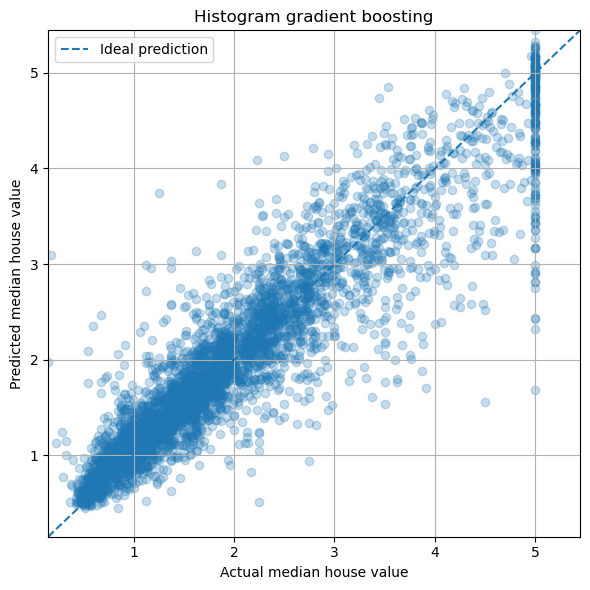

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_name = cv_results.iloc[0]["model"]
best_regressor = clone(models[best_name])
best_regressor.fit(X_train, y_train)

y_pred = best_regressor.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Selected workflow:", best_name)
print(f"Test MAE:  {test_mae:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test R2:   {test_r2:.3f}")

limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.25)
plt.plot(limits, limits, "--", label="Ideal prediction")
plt.xlim(limits)
plt.ylim(limits)
plt.xlabel("Actual median house value")
plt.ylabel("Predicted median house value")
plt.title(best_name)
plt.grid()
plt.legend()
plt.tight_layout()

The complete fitted workflow can be stored with `joblib`. Saving the pipeline, rather than only the final regressor, ensures that the same preprocessing is applied during inference:

In [8]:
import sklearn
from joblib import dump, load

artifact = {
    "model": best_regressor,
    "feature_names": list(X_train.columns),
    "sklearn_version": sklearn.__version__
}

dump(artifact, "../data/saved/california_housing.joblib")

loaded_artifact = load("../data/saved/california_housing.joblib")
loaded_model = loaded_artifact["model"]
new_predictions = loaded_model.predict(X_test.iloc[:3])
print(new_predictions)

[0.5710731  0.86984853 4.99243892]


## Project 2: numerical and categorical features <a id="Project2"></a>

The **Bank Marketing** dataset contains both numerical and categorical variables. The objective is to predict whether a customer will subscribe to a term deposit. This project illustrates how a `ColumnTransformer` can apply different preprocessing operations to different groups of columns.

The file `bank-full.csv` uses semicolon-separated fields:

In [9]:
import pandas as pd

bank = pd.read_csv("../data/bank-full.csv", sep=";")

X = bank.drop(columns="y")
y = bank["y"].map({"no": 0, "yes": 1})

print(X.dtypes)
print(y.value_counts(normalize=True))

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
dtype: object
y
0    0.883015
1    0.116985
Name: proportion, dtype: float64


The target is imbalanced, so accuracy alone is not sufficient. Moreover, the feature `duration` is known only after the telephone call has finished. If the model is intended to decide whom to contact before the call, retaining this feature would create an unrealistic prediction setting. We remove it for that use case:

In [10]:
X = X.drop(columns="duration")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

Numerical columns are imputed and standardized, whereas categorical columns are imputed and one-hot encoded. Unknown categories encountered at inference time are ignored rather than causing an exception:

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(include=["number"]).columns

categorical_features = X_train.select_dtypes(exclude=["number"]).columns

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=10
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessor, numeric_features),
    ("categorical", categorical_preprocessor,
     categorical_features)
])

We compare several classifiers by embedding a clone of the same preprocessor inside each pipeline:

In [12]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

classifiers = {
    "Logistic regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ),

    "Linear SVM": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ),

    "Decision tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "Random forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

bank_models = {
    name: Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", classifier)
    ])
    for name, classifier in classifiers.items()
}

We use stratified cross-validation and report balanced accuracy, $F_1$-score, ROC AUC, and average precision:

In [13]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

bank_results = compare_models(
    bank_models,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

bank_results = bank_results.sort_values(
    "average_precision_mean",
    ascending=False
)

print(bank_results[
    ["model", "balanced_accuracy_mean",
     "f1_mean", "roc_auc_mean",
     "average_precision_mean"]
])

                 model  balanced_accuracy_mean   f1_mean  roc_auc_mean  \
3        Random forest                0.696217  0.466432      0.791321   
0  Logistic regression                0.697228  0.372592      0.763673   
1           Linear SVM                0.696264  0.372914      0.763172   
2        Decision tree                0.707211  0.415675      0.755303   

   average_precision_mean  
3                0.437793  
0                0.398478  
1                0.394070  
2                0.374278  


The selected model (Random forest) is then fitted on all the training data and evaluated on the test set:

Selected workflow: Random forest
              precision    recall  f1-score   support

          no      0.930     0.933     0.932      7985
         yes      0.482     0.472     0.477      1058

    accuracy                          0.879      9043
   macro avg      0.706     0.702     0.704      9043
weighted avg      0.878     0.879     0.878      9043



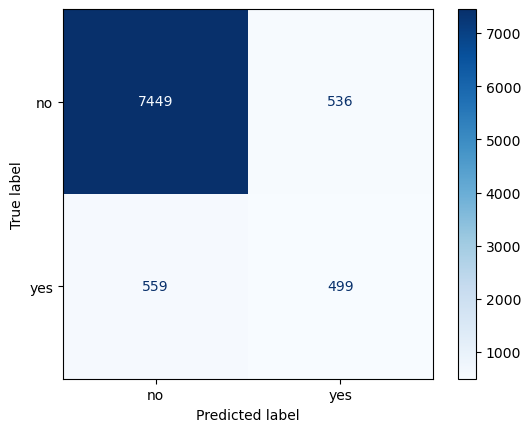

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_name = bank_results.iloc[0]["model"]
best_classifier = clone(bank_models[best_name])
best_classifier.fit(X_train, y_train)

y_pred = best_classifier.predict(X_test)

print("Selected workflow:", best_name)
print(classification_report(
    y_test,
    y_pred,
    target_names=["no", "yes"],
    digits=3
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["no", "yes"],
    cmap="Blues"
)

Finally, the complete pipeline can be persisted:

In [15]:
from joblib import dump

dump(best_classifier, "../data/saved/bank_marketing_pipeline.joblib")

['../data/saved/bank_marketing_pipeline.joblib']

## Project 3: missing values <a id="Project3"></a>


### Explicit missing values <a id="Explicit"></a>

The **Horse Colic** dataset contains missing entries explicitly represented by the symbol `?`. The processed CSV file used in this example stores the target in its final column:

In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/horse-colic.csv"

horse = pd.read_csv(url, header=None, na_values="?")

missing = horse.isna().sum()
missing_report = pd.DataFrame({
    "missing": missing,
    "percentage": 100 * missing / len(horse)
})

print(missing_report[
    missing_report["missing"] > 0
].sort_values("percentage", ascending=False))

    missing  percentage
15      247   82.333333
21      198   66.000000
20      165   55.000000
17      118   39.333333
14      106   35.333333
13      104   34.666667
16      102   34.000000
7        69   23.000000
3        60   20.000000
5        58   19.333333
12       56   18.666667
6        56   18.666667
10       55   18.333333
8        47   15.666667
11       44   14.666667
19       33   11.000000
9        32   10.666667
18       29    9.666667
4        24    8.000000
0         1    0.333333
22        1    0.333333


Before using a different version of the dataset, the location and meaning of the target column must be verified from its documentation. For this processed file:

In [17]:
X = horse.iloc[:, :-1].apply(pd.to_numeric, errors="coerce")
y = horse.iloc[:, -1].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

The imputation strategy is a hyperparameter and must therefore be selected inside cross-validation. Adding missing-value indicators can preserve information about which entries were originally unavailable:

In [18]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline

strategies = ["mean", "median", "most_frequent", "constant"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

strategy_rows = []

for strategy in strategies:
    pipeline = make_pipeline(
        SimpleImputer(strategy=strategy, add_indicator=True),
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro"
        },
        n_jobs=-1
    )

    strategy_rows.append({
        "strategy": strategy,
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean()
    })

strategy_results = pd.DataFrame(
    strategy_rows
).sort_values("balanced_accuracy_mean", ascending=False)

print(strategy_results)

        strategy  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean
0           mean                0.858203               0.050596       0.865782
1         median                0.851536               0.049017       0.862583
3       constant                0.848310               0.050122       0.857824
2  most_frequent                0.844869               0.043980       0.857145


The selected pipeline is fitted and persisted as a single object:

Test balanced accuracy: 0.75
[2 2 1]


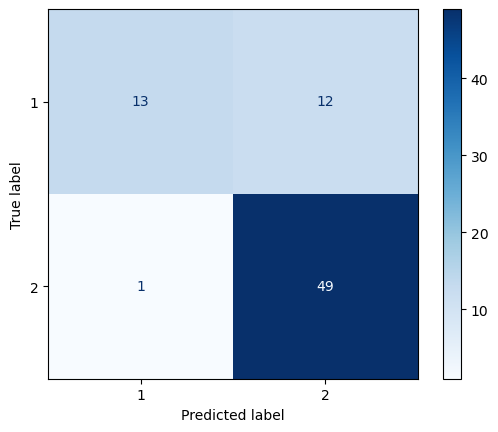

In [19]:
from joblib import dump, load
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score

best_strategy = strategy_results.iloc[0]["strategy"]

horse_pipeline = make_pipeline(
    SimpleImputer(strategy=best_strategy, add_indicator=True),
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
)

horse_pipeline.fit(X_train, y_train)
y_pred = horse_pipeline.predict(X_test)

print(
    "Test balanced accuracy:",
    balanced_accuracy_score(y_test, y_pred)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

dump(horse_pipeline, "../data/saved/horse_colic_pipeline.joblib")

loaded_pipeline = load("../data/saved/horse_colic_pipeline.joblib")
print(loaded_pipeline.predict(X_test.iloc[:3]))

### Disguised missing values <a id="Disguised"></a>

Some datasets use an apparently valid number as a placeholder for missing information. In the **Pima Indians Diabetes** dataset, zero is meaningful for the number of pregnancies but is physiologically implausible for measurements such as glucose concentration, blood pressure, and body mass index. The dataset can be obtained from **OpenML**:

In [20]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder

diabetes = fetch_openml(data_id=37, as_frame=True)

X = diabetes.data.apply(pd.to_numeric, errors="coerce")

y = LabelEncoder().fit_transform(diabetes.target)

print(X.head())
print(pd.Series(y).value_counts())

   preg  plas  pres  skin  insu  mass   pedi  age
0     6   148    72    35     0  33.6  0.627   50
1     1    85    66    29     0  26.6  0.351   31
2     8   183    64     0     0  23.3  0.672   32
3     1    89    66    23    94  28.1  0.167   21
4     0   137    40    35   168  43.1  2.288   33
0    500
1    268
Name: count, dtype: int64


The columns in positions 1--5 use zero as a missing-value marker. We replace these values before splitting, because this replacement does not estimate any statistics from the data:

In [21]:
zero_as_missing = X.columns[[1, 2, 3, 4, 5]]

X = X.copy()
X.loc[:, zero_as_missing] = X.loc[:, zero_as_missing].replace(0, np.nan)

print(X.isna().sum())

preg      0
plas      5
pres     35
skin    227
insu    374
mass     11
pedi      0
age       0
dtype: int64


C:\Users\miche\AppData\Local\Temp\ipykernel_37408\2745448209.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[148.  85. 183.  89. 137. 116.  78. 115. 197. 125. 110. 168. 139. 189.
 166. 100. 118. 107. 103. 115. 126.  99. 196. 119. 143. 125. 147.  97.
 145. 117. 109. 158.  88.  92. 122. 103. 138. 102.  90. 111. 180. 133.
 106. 171. 159. 180. 146.  71. 103. 105. 103. 101.  88. 176. 150.  73.
 187. 100. 146. 105.  84. 133.  44. 141. 114.  99. 109. 109.  95. 146.
 100. 139. 126. 129.  79.  nan  62.  95. 131. 112. 113.  74.  83. 101.
 137. 110. 106. 100. 136. 107.  80. 123.  81. 134. 142. 144.  92.  71.
  93. 122. 163. 151. 125.  81.  85. 126.  96. 144.  83.  95. 171. 155.
  89.  76. 160. 146. 124.  78.  97.  99. 162. 111. 107. 132. 113.  88.
 120. 118. 117. 105. 173. 122. 170.  84.  96. 125. 100.  93. 129. 105.
 128. 106. 108. 108. 154. 102.  57. 106. 147.  90. 136. 114. 156. 153.
 188. 152.  99. 109.  88. 163. 151

The imputation statistics and scaling parameters are instead learned only from the training data through a pipeline:

              precision    recall  f1-score   support

           0      0.822     0.776     0.798       125
           1      0.622     0.687     0.652        67

    accuracy                          0.745       192
   macro avg      0.722     0.731     0.725       192
weighted avg      0.752     0.745     0.747       192



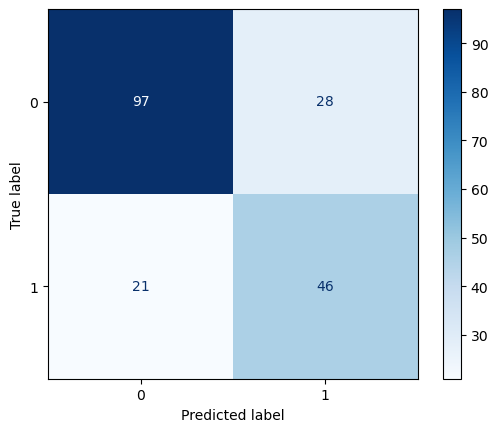

In [22]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

diabetes_pipeline = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    StandardScaler(),
    LogisticRegression(max_iter=3000, class_weight="balanced")
)

diabetes_pipeline.fit(X_train, y_train)
y_pred = diabetes_pipeline.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

## Project 4: handwritten-digit classification <a id="Project4"></a>

The Scikit-learn **digits** dataset contains 1,797 grayscale images of handwritten digits. Each image has $8 \times 8$ pixels and can therefore be represented by 64 numerical features:

In [23]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

print(digits.images.shape)
print(X.shape)

(1797, 8, 8)
(1797, 64)


The first 100 images can be displayed as follows:

C:\Users\miche\AppData\Local\Temp\ipykernel_37408\3358497662.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


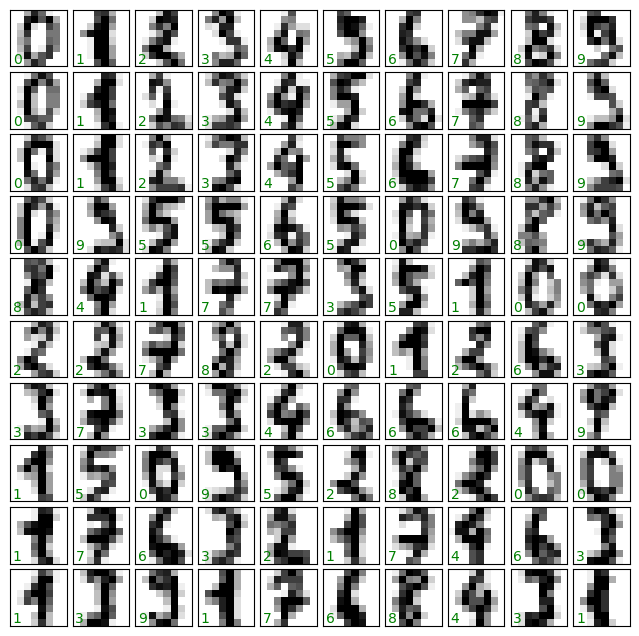

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    10,
    10,
    figsize=(8, 8),
    subplot_kw={"xticks": [], "yticks": []},
    gridspec_kw={"hspace": 0.1, "wspace": 0.1}
)

for i, ax in enumerate(axes.flat):
    ax.imshow(
        digits.images[i],
        cmap="binary",
        interpolation="nearest"
    )
    ax.text(
        0.05,
        0.05,
        str(digits.target[i]),
        color="green",
        transform=ax.transAxes
    )

plt.tight_layout()

An **Isomap** embedding provides a two-dimensional visualization of the nonlinear structure of the data. It is used only for visualization and not as input to the classifiers:

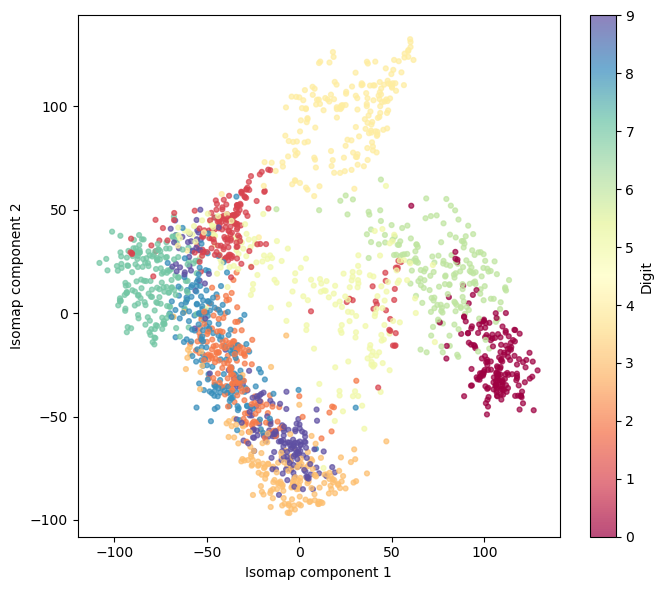

In [25]:
from sklearn.manifold import Isomap

embedding = Isomap(n_components=2, n_neighbors=10).fit_transform(X)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=y,
    s=12,
    alpha=0.7,
    cmap="Spectral"
)
plt.colorbar(scatter, label="Digit")
plt.xlabel("Isomap component 1")
plt.ylabel("Isomap component 2")
plt.tight_layout()

We reserve a stratified test set and compare Gaussian Naive Bayes with a random forest. The latter can represent nonlinear interactions among pixels, whereas the former assumes conditional independence within each class:

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

digit_models = {
    "Gaussian NB": GaussianNB(),
    "Random forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

digit_results = compare_models(
    digit_models,
    X_train,
    y_train,
    cv=cv,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"}
)

print(digit_results)

           model  fit_time_mean  fit_time_std  accuracy_mean  accuracy_std  \
0    Gaussian NB       0.005723      0.000516       0.831524      0.036381   
1  Random forest       1.565839      0.035662       0.976993      0.010854   

   f1_macro_mean  f1_macro_std  
0       0.832871      0.036181  
1       0.976735      0.011147  


Both models are then fitted for a detailed test-set comparison:


 Gaussian NB
Accuracy: 0.8288888888888889
              precision    recall  f1-score   support

           0      1.000     0.889     0.941        45
           1      0.745     0.826     0.784        46
           2      0.862     0.568     0.685        44
           3      1.000     0.717     0.835        46
           4      0.905     0.844     0.874        45
           5      0.935     0.935     0.935        46
           6      0.978     0.978     0.978        45
           7      0.759     0.978     0.854        45
           8      0.529     0.837     0.649        43
           9      0.842     0.711     0.771        45

    accuracy                          0.829       450
   macro avg      0.855     0.828     0.831       450
weighted avg      0.857     0.829     0.832       450


 Random forest
Accuracy: 0.9688888888888889
              precision    recall  f1-score   support

           0      1.000     0.956     0.977        45
           1      0.938     0.978     0.957 

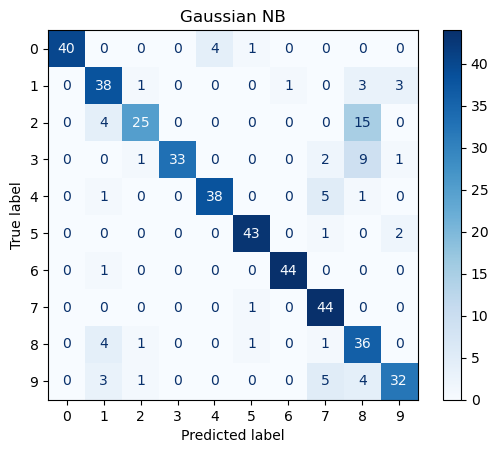

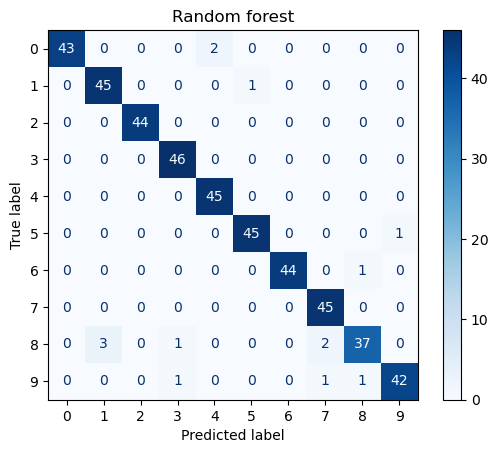

In [27]:
from sklearn.metrics import accuracy_score

predictions = {}

for name, model in digit_models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred = fitted_model.predict(X_test)
    predictions[name] = y_pred

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(name)

The error patterns can be inspected directly on the images:

C:\Users\miche\AppData\Local\Temp\ipykernel_37408\4006266161.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


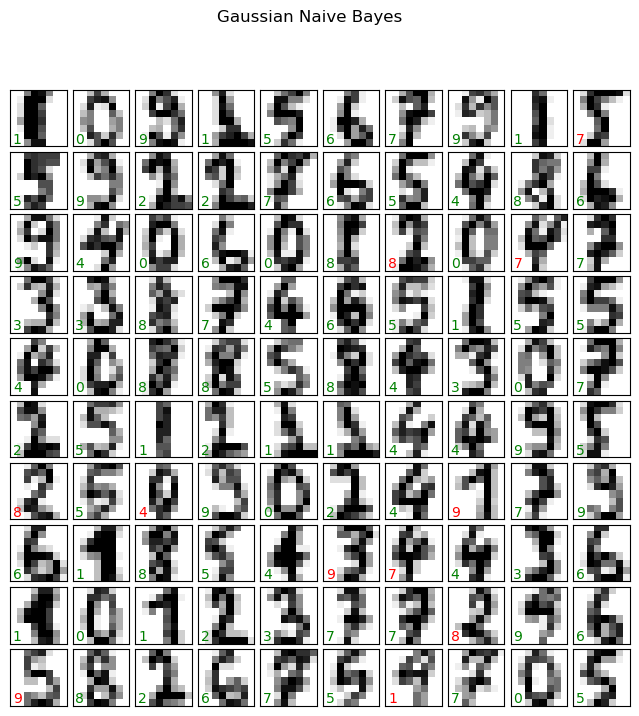

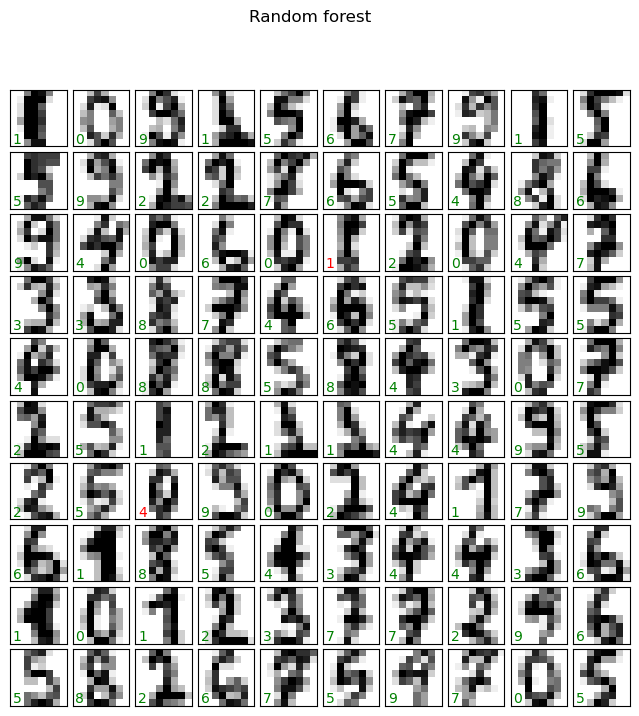

In [28]:
def plot_digit_predictions(X_test, y_test, y_pred,
        title, n_images=100):
    n_images = min(n_images, len(X_test))

    fig, axes = plt.subplots(
        10,
        10,
        figsize=(8, 8),
        subplot_kw={"xticks": [], "yticks": []},
        gridspec_kw={"hspace": 0.1, "wspace": 0.1}
    )

    for i, ax in enumerate(axes.flat):
        if i >= n_images:
            ax.axis("off")
            continue

        ax.imshow(
            X_test[i].reshape(8, 8),
            cmap="binary",
            interpolation="nearest"
        )

        colour = (
            "green"
            if y_pred[i] == y_test[i]
            else "red"
        )

        ax.text(
            0.05,
            0.05,
            str(y_pred[i]),
            color=colour,
            transform=ax.transAxes
        )

    fig.suptitle(title)
    plt.tight_layout()


plot_digit_predictions(
    X_test,
    y_test,
    predictions["Gaussian NB"],
    "Gaussian Naive Bayes"
)

plot_digit_predictions(
    X_test,
    y_test,
    predictions["Random forest"],
    "Random forest"
)

## Project 5: face recognition with SVMs <a id="Project5"></a>

The **Labeled Faces in the Wild** dataset contains images of public figures collected under uncontrolled conditions. To obtain a manageable multiclass problem, we retain only people represented by at least 60 images (few examples are shown below):

(1348, 1850)
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']


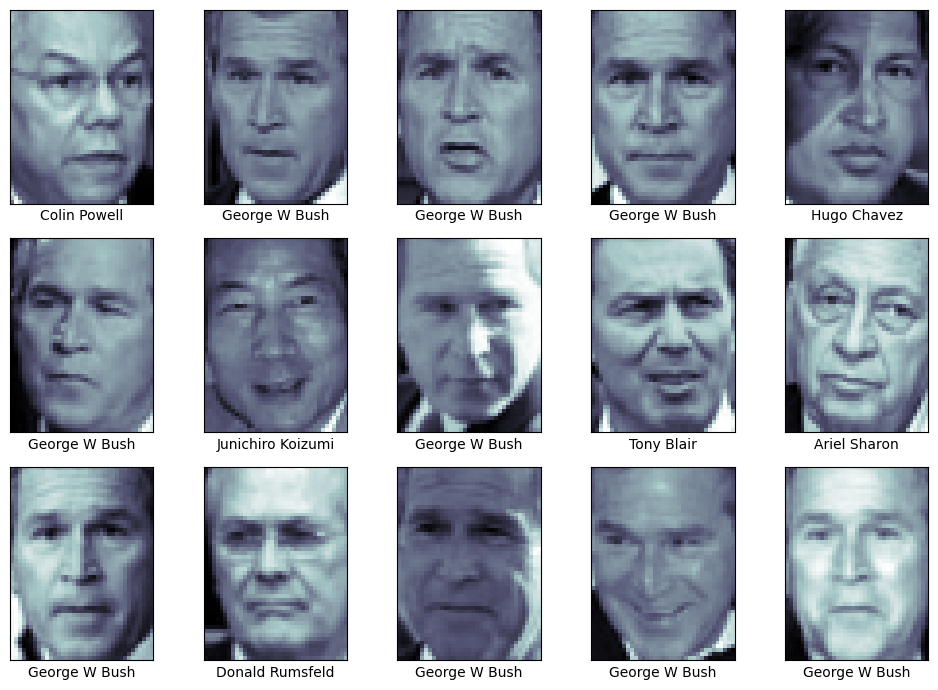

In [29]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=60, resize=0.4)

n_samples, image_height, image_width = faces.images.shape

X = faces.data
y = faces.target
target_names = faces.target_names

print(X.shape)
print(target_names)


fig, axes = plt.subplots(3, 5, figsize=(10, 7))

for i, ax in enumerate(axes.flat):
    ax.imshow(faces.images[i], cmap="bone")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(target_names[faces.target[i]])

plt.tight_layout()

Each image contains many correlated pixels. PCA reduces the dimensionality and its components can be interpreted as **eigenfaces**. Standardization, PCA, and the SVM are combined in one pipeline so that PCA is refitted independently within every cross-validation fold:

In [30]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

face_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(
        n_components=150,
        svd_solver="randomized",
        whiten=True,
        random_state=42
    )),
    ("svc", SVC(kernel="rbf", class_weight="balanced"))
])

The SVM hyperparameters are selected only from the training data:

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "svc__C": [1e3, 1e4, 1e5],
    "svc__gamma": [1e-4, 1e-3, 1e-2]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

search = GridSearchCV(
    face_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'svc__C': 1000.0, 'svc__gamma': 0.001}
0.7774653340102722


The selected model is evaluated on the test set:

                   precision    recall  f1-score   support

     Ariel Sharon      0.812     0.684     0.743        19
     Colin Powell      0.779     0.898     0.835        59
  Donald Rumsfeld      0.800     0.800     0.800        30
    George W Bush      0.909     0.902     0.906       133
Gerhard Schroeder      0.862     0.926     0.893        27
      Hugo Chavez      0.857     0.667     0.750        18
Junichiro Koizumi      1.000     0.733     0.846        15
       Tony Blair      0.784     0.806     0.795        36

         accuracy                          0.852       337
        macro avg      0.850     0.802     0.821       337
     weighted avg      0.855     0.852     0.851       337



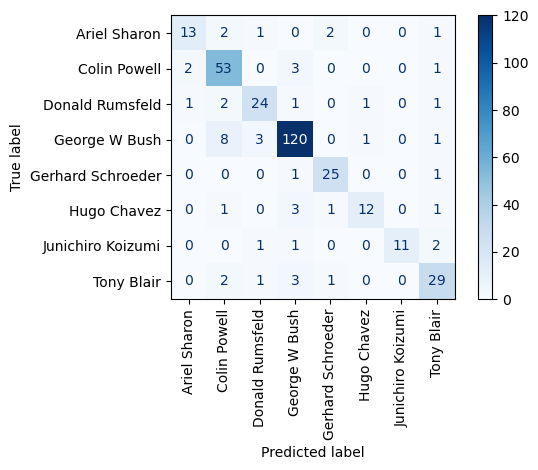

In [32]:
best_face_model = search.best_estimator_
y_pred = best_face_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=3,
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_names,
    xticks_rotation=90,
    cmap="Blues"
)
plt.tight_layout()

To inspect individual decisions, we display a sample of test images (using red labels for incorrect predictions):

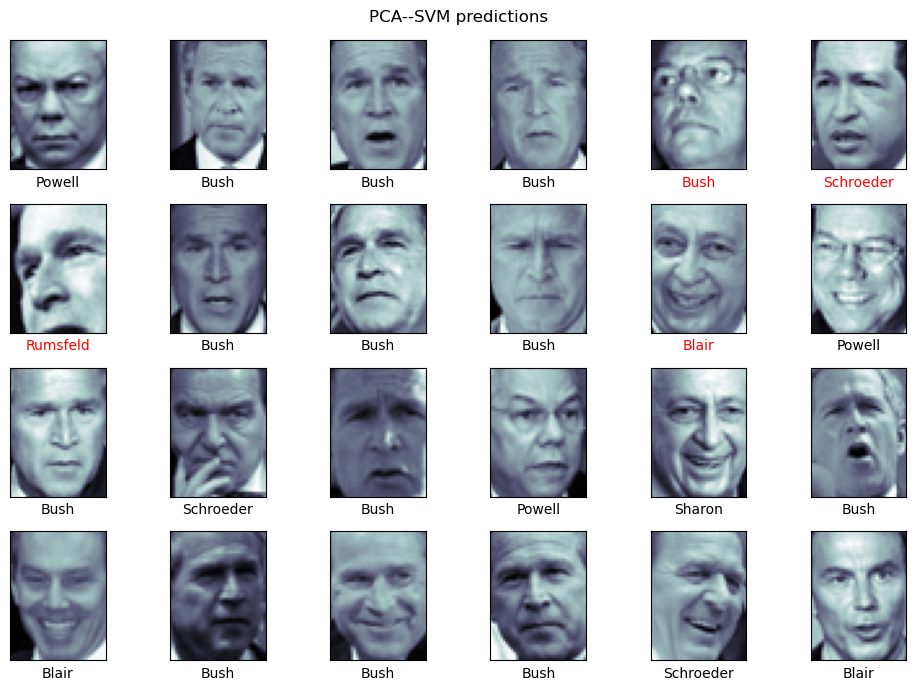

In [33]:
def plot_face_predictions(X_test, y_test, y_pred,
        target_names, image_height, image_width,
        title, n_rows=4, n_columns=6):
    
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(10, 7))

    for i, ax in enumerate(axes.flat):
        if i >= len(X_test):
            ax.axis("off")
            continue

        ax.imshow(
            X_test[i].reshape(image_height, image_width),
            cmap="bone"
        )
        ax.set_xticks([])
        ax.set_yticks([])

        predicted_name = target_names[y_pred[i]].split()[-1]

        colour = (
            "black"
            if y_pred[i] == y_test[i]
            else "red"
        )

        ax.set_xlabel(predicted_name, color=colour)

    fig.suptitle(title)
    plt.tight_layout()


plot_face_predictions(
    X_test,
    y_test,
    y_pred,
    target_names,
    image_height,
    image_width,
    "PCA--SVM predictions"
)

A Gaussian Naive Bayes classifier can be used as a simpler reference after the same PCA transformation:

                   precision    recall  f1-score   support

     Ariel Sharon      0.571     0.421     0.485        19
     Colin Powell      0.462     0.407     0.432        59
  Donald Rumsfeld      0.875     0.467     0.609        30
    George W Bush      0.570     0.797     0.665       133
Gerhard Schroeder      0.842     0.593     0.696        27
      Hugo Chavez      0.667     0.333     0.444        18
Junichiro Koizumi      0.643     0.600     0.621        15
       Tony Blair      0.556     0.417     0.476        36

         accuracy                          0.588       337
        macro avg      0.648     0.504     0.553       337
     weighted avg      0.607     0.588     0.577       337



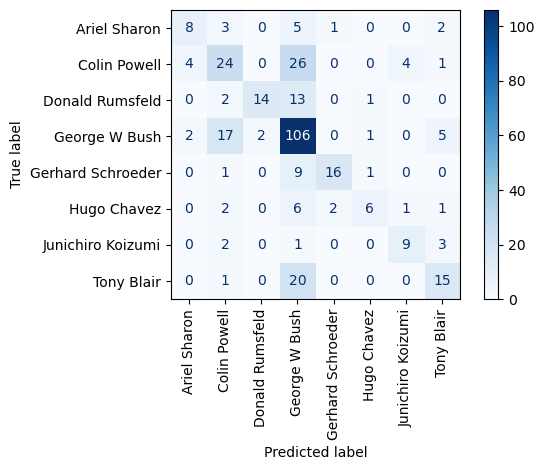

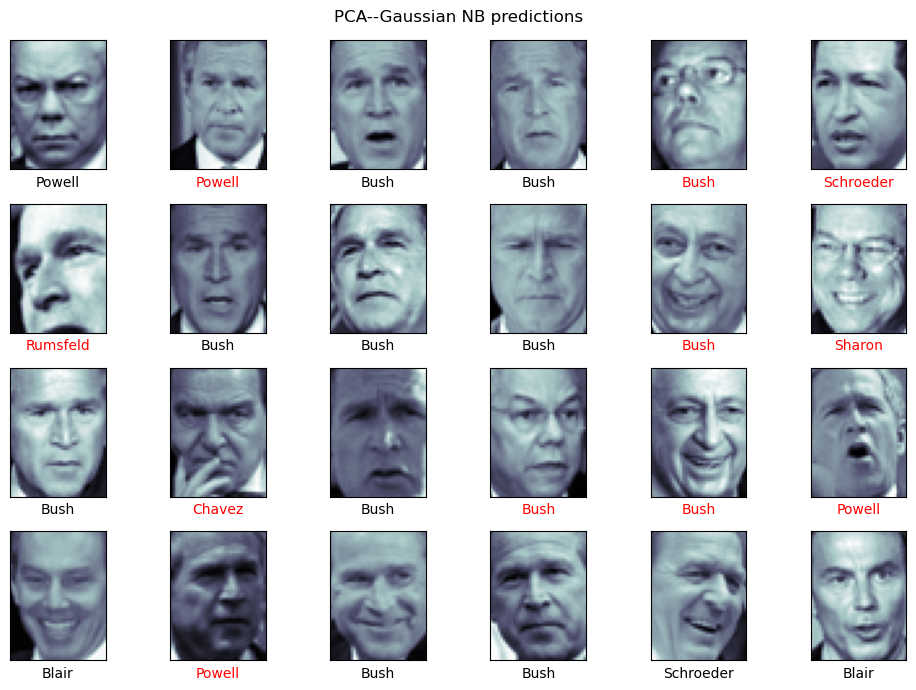

In [34]:
from sklearn.naive_bayes import GaussianNB

face_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(
        n_components=150,
        svd_solver="randomized",
        whiten=True,
        random_state=42
    )),
    ("classifier", GaussianNB())
])

face_nb.fit(X_train, y_train)
y_pred_nb = face_nb.predict(X_test)

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=target_names,
    digits=3,
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels=target_names,
    xticks_rotation=90,
    cmap="Blues"
)
plt.tight_layout()

plot_face_predictions(
    X_test,
    y_test,
    y_pred_nb,
    target_names,
    image_height,
    image_width,
    "PCA--Gaussian NB predictions"
)

## Project 6: SMS spam detection <a id="Project6"></a>

**Spam detection** is a binary text-classification problem in which messages are labelled as legitimate (*ham*) or unsolicited (*spam*). We use the SMS Spam Collection dataset, which is distributed as a tab-separated text file:

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split

spam = pd.read_csv(
    "../data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "text"]
)

spam["label"] = spam["label"].map({"ham": 0, "spam": 1})

print(spam.shape)
print(spam["label"].value_counts())
print(spam["label"].value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    spam["text"],
    spam["label"],
    test_size=0.20,
    stratify=spam["label"],
    random_state=42
)

(5572, 2)
label
0    4825
1     747
Name: count, dtype: int64
label
0    0.865937
1    0.134063
Name: proportion, dtype: float64


### A bag-of-words baseline <a id="BoW"></a>

The **bag-of-words** model represents a message by the occurrences of its tokens, disregarding their global order. Contiguous sequences of $n$ tokens are called $n$-grams.

A complete baseline combines `CountVectorizer` and multinomial Naive Bayes in one pipeline:

In [36]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

bow_nb = Pipeline([
    ("vectorizer", CountVectorizer(min_df=2, ngram_range=(1, 1))),
    ("classifier", MultinomialNB())
])

bow_nb.fit(X_train, y_train)
y_pred_nb = bow_nb.predict(X_test)
y_score_nb = bow_nb.predict_proba(X_test)[:, 1]

The model is evaluated using thresholded predictions and continuous positive class probabilities:

{'precision': 0.9857142857142858, 'recall': 0.9261744966442953, 'f1': 0.9550173010380623, 'roc_auc': 0.9811858212791974, 'average_precision': 0.9648733415184282}
              precision    recall  f1-score   support

         ham      0.989     0.998     0.993       966
        spam      0.986     0.926     0.955       149

    accuracy                          0.988      1115
   macro avg      0.987     0.962     0.974      1115
weighted avg      0.988     0.988     0.988      1115



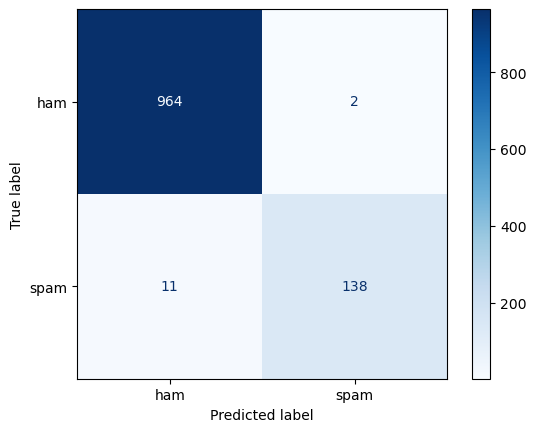

In [37]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import average_precision_score, roc_auc_score

def evaluate_binary_classifier(y_true, y_pred, y_score):
    return {
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score)
    }

print(evaluate_binary_classifier(
    y_test,
    y_pred_nb,
    y_score_nb
))

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["ham", "spam"],
    digits=3
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels=["ham", "spam"],
    cmap="Blues"
)

### TF-IDF and hyperparameter selection <a id="TFIDF"></a>

Raw word counts may assign excessive importance to terms that appear in many documents. The *term frequency-inverse document frequency* representation is defined as:
$$
\operatorname{tfidf}(t,d) = \operatorname{tf}(t,d) \times \operatorname{idf}(t),
$$
where, using the smoothed Scikit-learn convention:
$$
\operatorname{idf}(t) = \log\left( \frac{1+n}{1+\operatorname{df}(t)} \right)+1.
$$
Here, $n$ is the number of training documents and $\text{df}(t)$ is the number of training documents containing term $t$.

`TfidfVectorizer` combines tokenization, vocabulary construction, counting, inverse-document-frequency weighting, and vector normalization. A pipeline prevents its vocabulary and IDF statistics from being estimated on validation or test documents:

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(strip_accents="unicode", lowercase=True)),
    ("classifier", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

The grid explores unigrams and bigrams, minimum document frequencies, sublinear term frequency, and the logistic-regression regularization strength:

In [39]:
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__sublinear_tf": [False, True],
    "classifier__C": [0.1, 1.0, 10.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

spam_search = GridSearchCV(
    tfidf_lr,
    param_grid=param_grid,
    scoring={
        "average_precision": "average_precision",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    refit="average_precision",
    cv=cv,
    n_jobs=-1
)

spam_search.fit(X_train, y_train)

print(spam_search.best_params_)
print(spam_search.best_score_)

{'classifier__C': 10.0, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
0.9823110723972002


The final test evaluation is performed only after the search has finished:

{'precision': 0.971830985915493, 'recall': 0.9261744966442953, 'f1': 0.9484536082474226, 'roc_auc': 0.9919268553642642, 'average_precision': 0.977428872841189}
              precision    recall  f1-score   support

         ham      0.989     0.996     0.992       966
        spam      0.972     0.926     0.948       149

    accuracy                          0.987      1115
   macro avg      0.980     0.961     0.970      1115
weighted avg      0.986     0.987     0.986      1115



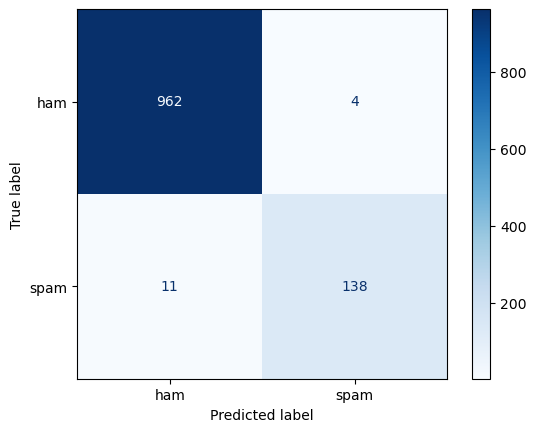

In [40]:
best_spam_model = spam_search.best_estimator_

y_pred_lr = best_spam_model.predict(X_test)
y_score_lr = best_spam_model.predict_proba(X_test)[:, 1]

print(evaluate_binary_classifier(
    y_test,
    y_pred_lr,
    y_score_lr
))

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["ham", "spam"],
    digits=3
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["ham", "spam"],
    cmap="Blues"
)

We first persist the complete TF-IDF and logistic-regression workflow:

In [41]:
from joblib import dump

dump(best_spam_model, "../data/saved/spam_pipeline.joblib")

['../data/saved/spam_pipeline.joblib']

### Incremental and out-of-core learning <a id="OOC"></a>

When all documents cannot be stored in memory, a stateless `HashingVectorizer` can be combined with an estimator supporting `partial_fit`. The following example processes the training messages in mini-batches:

In [42]:
import numpy as np
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import SGDClassifier

hashing = HashingVectorizer(n_features=2**18, alternate_sign=False, norm="l2")

online_classifier = SGDClassifier(loss="log_loss", random_state=42)

classes = np.array([0, 1])
batch_size = 256

X_train_array = X_train.to_numpy()
y_train_array = y_train.to_numpy()

for start in range(0, len(X_train_array), batch_size):
    stop = start + batch_size

    X_batch = hashing.transform(X_train_array[start:stop])
    y_batch = y_train_array[start:stop]

    online_classifier.partial_fit(X_batch, y_batch, classes=classes)

X_test_hashed = hashing.transform(X_test)
y_pred_online = online_classifier.predict(X_test_hashed)

print(classification_report(
    y_test,
    y_pred_online,
    target_names=["ham", "spam"],
    digits=3
))

              precision    recall  f1-score   support

         ham      0.974     0.997     0.985       966
        spam      0.976     0.826     0.895       149

    accuracy                          0.974      1115
   macro avg      0.975     0.911     0.940      1115
weighted avg      0.974     0.974     0.973      1115



## A minimal web application <a id="Web"></a>

A fitted text pipeline accepts raw strings and is therefore convenient for deployment. A minimal Flask application requires:
- the trusted fitted model artifact;
- an HTML form for entering a message;
- a route that validates the input and returns a prediction;
- optionally, a database for logging predictions and later feedback.

The following example creates the database table, loads the pipeline, and defines one route for both the input form and the prediction:

In [43]:
from pathlib import Path
import sqlite3

from flask import Flask, render_template, request
from joblib import load

app = Flask(__name__)

MODEL_PATH = Path("../data/saved/spam_pipeline.joblib")
DATABASE_PATH = Path("../data/emails.sqlite")

model = load(MODEL_PATH)

def initialise_database():
    with sqlite3.connect(DATABASE_PATH) as conn:
        conn.execute("""
            CREATE TABLE IF NOT EXISTS predictions (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                text TEXT NOT NULL,
                predicted_label INTEGER NOT NULL,
                probability REAL NOT NULL,
                created_at TEXT DEFAULT CURRENT_TIMESTAMP
            )
        """)


def log_prediction(text, predicted_label, probability):
    with sqlite3.connect(DATABASE_PATH) as conn:
        conn.execute(
            """
            INSERT INTO predictions
                (text, predicted_label, probability)
            VALUES (?, ?, ?)
            """,
            (
                text,
                predicted_label,
                probability
            )
        )


@app.route("/", methods=["GET", "POST"])
def index():
    if request.method == "GET":
        return render_template("emailform.html")

    text = request.form.get("emailtext", "").strip()

    if not text:
        return render_template(
            "emailform.html",
            error="Please enter a message."
        )

    predicted_label = int(model.predict([text])[0])

    probability = float(model.predict_proba([text])[0, 1])

    log_prediction(text, predicted_label, probability)

    return render_template(
        "results.html",
        content=text,
        prediction=(
            "spam"
            if predicted_label == 1
            else "ham"
        ),
        probability=100 * probability
    )


if __name__ == "__main__":
    initialise_database()
    app.run(debug=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
[2026-09-24 23:18:01,820] ERROR in app: Exception on / [GET]
Traceback (most recent call last):
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\site-packages\flask\app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\site-packages\flask\app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\site-packages\flask\app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\site-packages\flask\app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File 

> The associated HTML templates are intentionally omitted because web-interface design is outside the scope of this book. 

To running a working example of the web application, please refer to the script-based implamentation.